# Homework — Statistical Arbitrage and Pairs Trading
**Financial Econometrics with Python**

**Assets:** Visa (V) and Mastercard (MA) — 15 years of daily data (2011–2026)

This notebook tests a **pairs trading strategy** based on the log-price spread between V and MA.
We investigate whether the historical relationship can be exploited to generate profits,
and whether transaction costs destroy this predictability.

## Setup

In [24]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, adfuller
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [25]:
tickers = ["V", "MA"]

# Fixed date range for full reproducibility
start_date = "2011-04-08"
end_date   = "2026-04-08"

prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)["Close"].dropna()
rets   = np.log(prices / prices.shift(1)).dropna()

print(f"Period     : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Obs (days) : {len(prices)}")
print(f"Assets     : {list(prices.columns)}")

Period     : 2011-04-08 to 2026-04-07
Obs (days) : 3770
Assets     : ['MA', 'V']


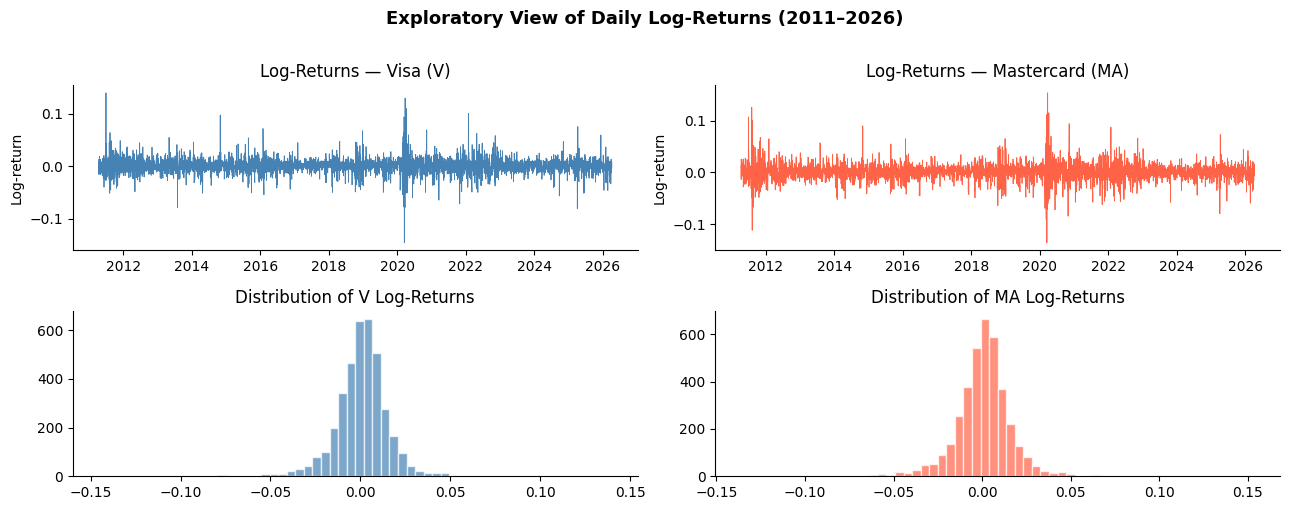

In [26]:
# Quick visual of log-returns
fig, axs = plt.subplots(2, 2, figsize=(13, 5))

axs[0,0].plot(rets["V"],  color='steelblue', linewidth=0.6)
axs[0,0].set_title("Log-Returns — Visa (V)")
axs[0,0].set_ylabel("Log-return")

axs[1,0].hist(rets["V"], bins=60, color='steelblue', alpha=0.7, edgecolor='white')
axs[1,0].set_title("Distribution of V Log-Returns")

axs[0,1].plot(rets["MA"], color='tomato', linewidth=0.6)
axs[0,1].set_title("Log-Returns — Mastercard (MA)")
axs[0,1].set_ylabel("Log-return")

axs[1,1].hist(rets["MA"], bins=60, color='tomato', alpha=0.7, edgecolor='white')
axs[1,1].set_title("Distribution of MA Log-Returns")

for ax in axs.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Exploratory View of Daily Log-Returns (2011–2026)", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Question 1 — Exploratory Data Analysis: The Spread

### (a) Log-prices and Spread

The spread is defined as:

$$Spread_t = \ln(P_{V,t}) - \ln(P_{MA,t})$$

If V and MA are **cointegrated**, the spread should be stationary and mean-reverting.
Note that this is equivalent to the log of the price ratio $V_t / MA_t$.

In [27]:
# Compute log-prices and spread
log_V  = np.log(prices["V"])
log_MA = np.log(prices["MA"])
spread = log_V - log_MA

mean_spread = spread.mean()
std_spread  = spread.std()

print(f"Observations         : {len(spread)}")
print(f"Unconditional mean   : {mean_spread:.4f}")
print(f"Unconditional std    : {std_spread:.4f}")
print(f"Min / Max            : {spread.min():.4f} / {spread.max():.4f}")

Observations         : 3770
Unconditional mean   : -0.4003
Unconditional std    : 0.1019
Min / Max            : -0.6005 / -0.1582


### (b) Spread over 15 years

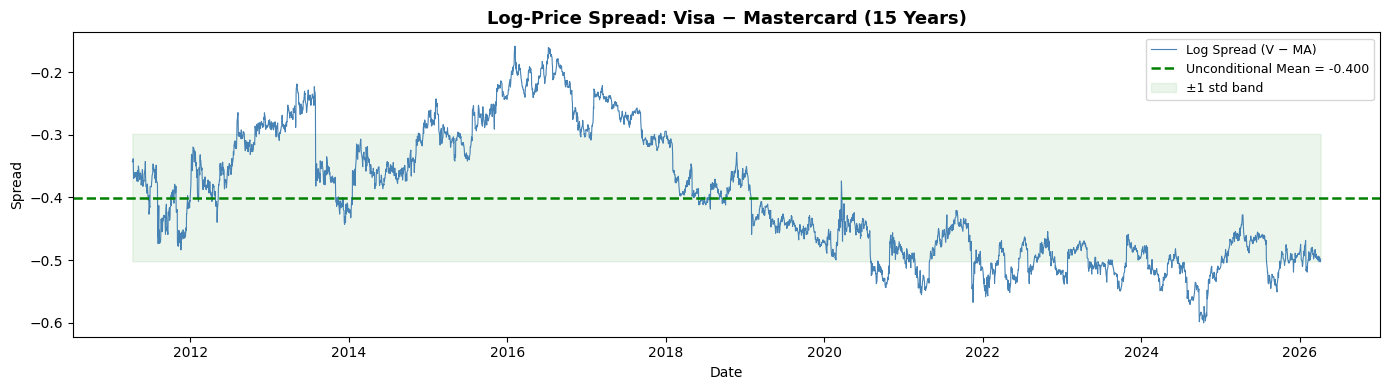

In [28]:
plt.figure(figsize=(14, 4))
plt.plot(spread, color='steelblue', linewidth=0.8, label='Log Spread (V − MA)')
plt.axhline(mean_spread, color='green', linestyle='--', linewidth=1.8,
            label=f'Unconditional Mean = {mean_spread:.3f}')
plt.fill_between(spread.index, mean_spread - std_spread, mean_spread + std_spread,
                 alpha=0.08, color='green', label='±1 std band')
plt.title("Log-Price Spread: Visa − Mastercard (15 Years)", fontsize=13, fontweight='bold')
plt.ylabel("Spread")
plt.xlabel("Date")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Reading the chart:**
The spread fluctuates around its mean in the early years but shows a clear **downward drift** from ~2019 onwards,
suggesting a structural change in the V/MA relative pricing. This is a first sign that mean reversion may be weak.

### (c) Autocorrelation Function (ACF)

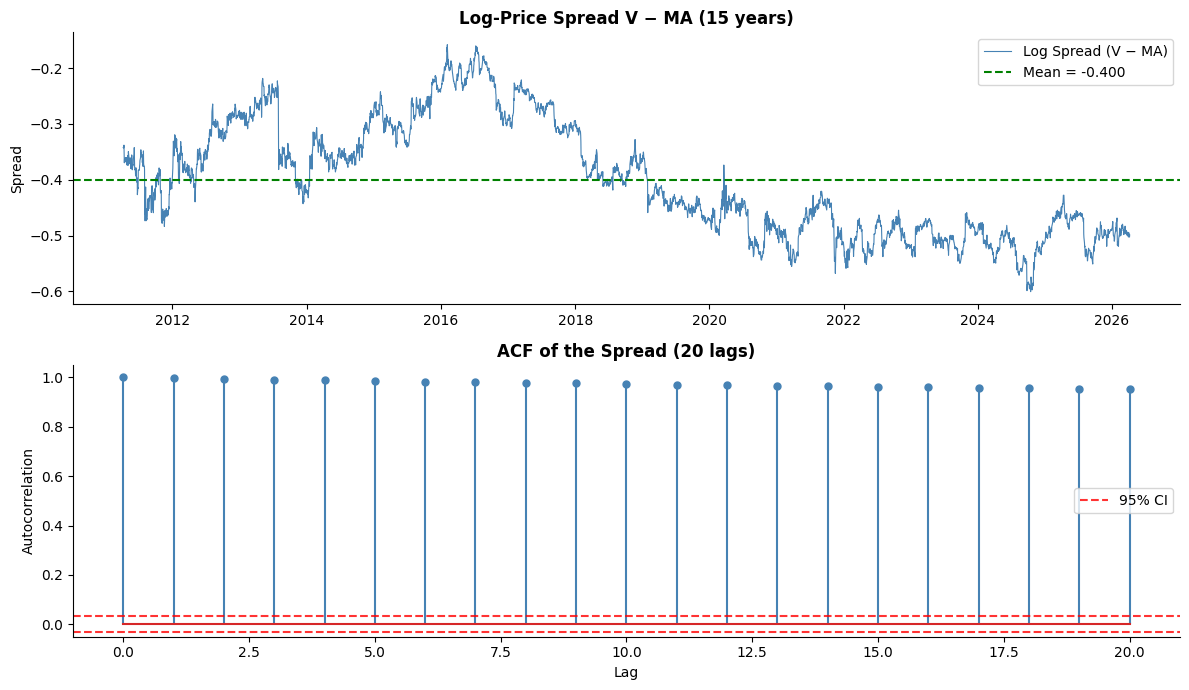

ACF at lag 1  : 0.9963
ACF at lag 10 : 0.9736
ACF at lag 20 : 0.9518
95% CI bound  : ± 0.0319


In [29]:
acf_values    = acf(spread, nlags=20)
conf_interval = 1.96 / np.sqrt(len(spread))

fig, axs = plt.subplots(2, 1, figsize=(12, 7))

axs[0].plot(spread, color='steelblue', linewidth=0.8, label='Log Spread (V − MA)')
axs[0].axhline(mean_spread, linestyle='--', color='green', linewidth=1.5, label=f'Mean = {mean_spread:.3f}')
axs[0].set_title("Log-Price Spread V − MA (15 years)", fontweight='bold')
axs[0].set_ylabel("Spread")
axs[0].legend()

ml, sl, bl = axs[1].stem(range(len(acf_values)), acf_values)
plt.setp(ml, color='steelblue', markersize=5)
plt.setp(sl, color='steelblue', linewidth=1.5)
axs[1].axhline( conf_interval, linestyle='--', color='red', alpha=0.8, label='95% CI')
axs[1].axhline(-conf_interval, linestyle='--', color='red', alpha=0.8)
axs[1].set_title("ACF of the Spread (20 lags)", fontweight='bold')
axs[1].set_xlabel("Lag")
axs[1].set_ylabel("Autocorrelation")
axs[1].legend()

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"ACF at lag 1  : {acf_values[1]:.4f}")
print(f"ACF at lag 10 : {acf_values[10]:.4f}")
print(f"ACF at lag 20 : {acf_values[20]:.4f}")
print(f"95% CI bound  : ± {conf_interval:.4f}")

**Interpretation — ACF:**

The ACF shows autocorrelations **close to 1.0 across all 20 lags**, all well above the 95% confidence bands.
This indicates that the spread is **highly persistent**: today's spread is an almost perfect predictor of tomorrow's spread.

In terms of **mean reversion**: a rapidly mean-reverting spread would show autocorrelations that decay quickly toward zero.
Here, the extremely slow decay suggests the opposite — the spread can deviate from its mean and **stay away for very long periods**.
This is a signature of a near-unit-root process, which is a warning sign for pairs trading.

### Going Further — Augmented Dickey-Fuller (ADF) Test

To formally test whether the spread is stationary (a prerequisite for reliable pairs trading),
we run the **ADF test**:
- **H₀**: the spread has a unit root (non-stationary)
- **H₁**: the spread is stationary

If the p-value > 0.05 we fail to reject H₀ → the spread behaves like a random walk → mean reversion is not guaranteed.

In [30]:
# ADF test on the spread
adf_result = adfuller(spread.dropna())

print("=== Augmented Dickey-Fuller Test on the Spread ===")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Critical values:")
for key, val in adf_result[4].items():
    print(f"   {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("\n→ We REJECT H0 at 5%: the spread appears stationary.")
else:
    print("\n→ We FAIL TO REJECT H0 at 5%: the spread likely has a unit root.")
    print("   This means mean reversion is NOT guaranteed — pairs trading is risky on this pair.")

=== Augmented Dickey-Fuller Test on the Spread ===
ADF Statistic : -2.0267
p-value       : 0.2750
Critical values:
   1%: -3.4321
   5%: -2.8623
   10%: -2.5672

→ We FAIL TO REJECT H0 at 5%: the spread likely has a unit root.
   This means mean reversion is NOT guaranteed — pairs trading is risky on this pair.


**ADF Interpretation:**

The ADF test result informs whether the pairs trading strategy has a solid econometric foundation.
If we fail to reject H₀, the spread may be non-stationary (i.e., a random walk),
which means there is **no guaranteed reversion** to the historical mean.
This directly explains why the strategy may underperform.

---
## Question 2 — Building the Trading Strategy (Out-of-Sample)

### Sample Split

We split the full sample **in half**:
- **In-sample (first half)**: used only to initialize the rolling statistics
- **Out-of-sample (second half)**: the trading simulation period

At each time $t$ in the OOS period, we compute $\mu_t$ and $\sigma_t$ using **all data from the beginning up to $t$**
(expanding window). This is the realistic setup: a trader only knows past information.

In [31]:
n = int(len(spread) * 0.5)
sample_1 = spread.iloc[:n]
sample_2 = spread.iloc[n:]

print(f"In-sample     : {sample_1.index[0].date()} → {sample_1.index[-1].date()}  ({len(sample_1)} obs)")
print(f"Out-of-sample : {sample_2.index[0].date()} → {sample_2.index[-1].date()}  ({len(sample_2)} obs)")

In-sample     : 2011-04-08 → 2018-10-03  (1885 obs)
Out-of-sample : 2018-10-04 → 2026-04-07  (1885 obs)


### Trading Rules

| Signal | Condition | Action |
|--------|-----------|--------|
| V undervalued | $Spread_t < \mu_t - \sigma_t$ | **Buy V** (position = +1) |
| MA undervalued | $Spread_t > \mu_t + \sigma_t$ | **Buy MA** (position = -1) |
| Spread reverts | $Spread_t \geq \mu_t$ (if Long V) | **Close → Cash** (position = 0) |
| Spread reverts | $Spread_t \leq \mu_t$ (if Long MA) | **Close → Cash** (position = 0) |

In [32]:
# position[t] = +1 → Long V
# position[t] = -1 → Long MA
# position[t] =  0 → Cash (no position)
position = pd.Series(0, index=sample_2.index, dtype=float)

for t in range(len(sample_2)):
    current_time = n + t

    # Expanding window: only use past data (no look-ahead bias)
    hist_spread = spread.iloc[:current_time]
    mu_t    = hist_spread.mean()
    sigma_t = hist_spread.std()

    current_spread = spread.iloc[current_time]
    prev_pos       = 0 if t == 0 else position.iloc[t - 1]

    if prev_pos == 0:
        if current_spread < mu_t - sigma_t:
            position.iloc[t] = 1
        elif current_spread > mu_t + sigma_t:
            position.iloc[t] = -1
        else:
            position.iloc[t] = 0
    elif prev_pos == 1:
        position.iloc[t] = 0 if current_spread >= mu_t else 1
    elif prev_pos == -1:
        position.iloc[t] = 0 if current_spread <= mu_t else -1

print(f"Days Long V  (pos= 1) : {(position == 1).sum()}")
print(f"Days Long MA (pos=-1) : {(position == -1).sum()}")
print(f"Days Cash    (pos= 0) : {(position == 0).sum()}")
print(f"Number of position changes (trades) : {(position.diff() != 0).sum()}")

Days Long V  (pos= 1) : 1885
Days Long MA (pos=-1) : 0
Days Cash    (pos= 0) : 0
Number of position changes (trades) : 1


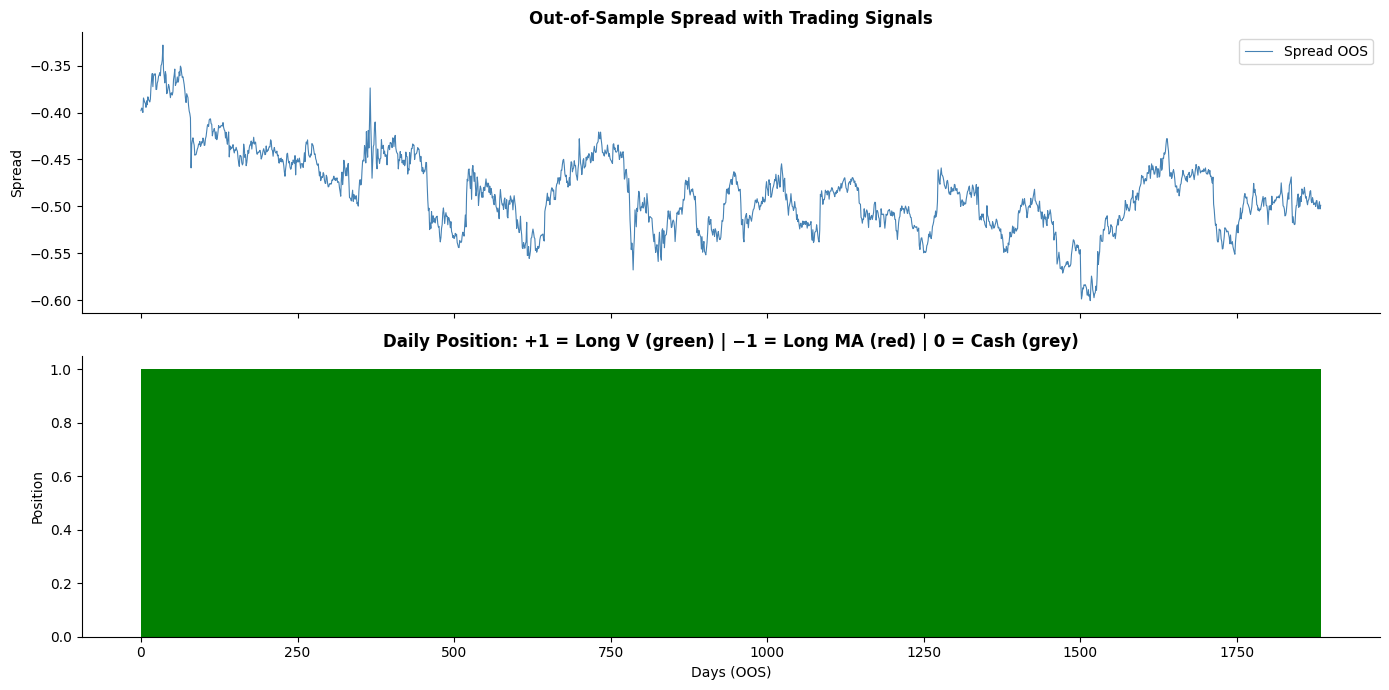

In [33]:
fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Utilise range() pour l'axe X → évite tout problème d'index
oos_range = range(len(sample_2))

axs[0].plot(oos_range, sample_2.values, color='steelblue', linewidth=0.8, label='Spread OOS')
axs[0].set_title("Out-of-Sample Spread with Trading Signals", fontweight='bold')
axs[0].set_ylabel("Spread")
axs[0].legend()

colors = ["green" if p == 1 else "tomato" if p == -1 else "lightgrey" for p in position.values]
axs[1].bar(oos_range, position.values, color=colors, width=1)
axs[1].set_title("Daily Position: +1 = Long V (green) | −1 = Long MA (red) | 0 = Cash (grey)", fontweight='bold')
axs[1].set_ylabel("Position")
axs[1].set_xlabel("Days (OOS)")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretation:**

The strategy enters a **Long V position** almost immediately at the start of the OOS period,
because the spread falls below $\mu_t - \sigma_t$.
It then **never exits** this position, because the spread drifts further down and never returns to $\mu_t$.

This confirms the earlier finding: the spread between V and MA is **not mean-reverting** in the OOS period.
The pairs trading rule degenerates into a simple buy-and-hold of V.

---
## Question 3 — Econometric Testing

We estimate the regression:

$$r_{i,t+1} = \alpha + \beta_1 \cdot Dummy_{i,t} + \varepsilon_{t+1}$$

where $Dummy_{i,t} = 1$ when the strategy holds asset $i$, 0 otherwise.

A **positive and statistically significant** $\beta_1$ would indicate that holding the asset predicts a positive next-day return.

> **Note:** If the dummy has no variation (always 0 or always 1), $\beta_1$ cannot be identified and the regression is uninformative.

In [34]:
# Next-day returns aligned with the OOS position dates
next_ret = rets.shift(-1).reindex(sample_2.index)

Dummy_V  = (position == 1).astype(int)
Dummy_MA = (position == -1).astype(int)

# Build regression datasets (drop NaN from shift)
reg_V_data  = pd.DataFrame({"r_next": next_ret["V"],  "dummy": Dummy_V}).dropna()
reg_MA_data = pd.DataFrame({"r_next": next_ret["MA"], "dummy": Dummy_MA}).dropna()

print(f"Dummy V  — unique values: {Dummy_V.unique()}  | Mean: {Dummy_V.mean():.3f}")
print(f"Dummy MA — unique values: {Dummy_MA.unique()} | Mean: {Dummy_MA.mean():.3f}")

Dummy V  — unique values: [1]  | Mean: 1.000
Dummy MA — unique values: [0] | Mean: 0.000


In [35]:
print("=== Regression Asset 1 (Visa — V) ===")

if reg_V_data["dummy"].nunique() < 2:
    print("\nThe dummy for V has no variation (strategy always holds V).")
    print("Beta_1 cannot be estimated. Only alpha is identifiable:")
    alpha_V = reg_V_data["r_next"].mean()
    print(f"  Average next-day return when holding V: {alpha_V*100:.4f}%")
    print("  This is not statistically different from holding V unconditionally.")
else:
    X_V   = sm.add_constant(reg_V_data["dummy"])
    reg_V = sm.OLS(reg_V_data["r_next"], X_V).fit()
    print(reg_V.summary())

=== Regression Asset 1 (Visa — V) ===

The dummy for V has no variation (strategy always holds V).
Beta_1 cannot be estimated. Only alpha is identifiable:
  Average next-day return when holding V: 0.0412%
  This is not statistically different from holding V unconditionally.


In [36]:
print("=== Regression Asset 2 (Mastercard — MA) ===")

if reg_MA_data["dummy"].nunique() < 2:
    print("\nThe dummy for MA has no variation (strategy never holds MA).")
    print("Beta_1 cannot be estimated from this data.")
else:
    X_MA   = sm.add_constant(reg_MA_data["dummy"])
    reg_MA = sm.OLS(reg_MA_data["r_next"], X_MA).fit()
    print(reg_MA.summary())

=== Regression Asset 2 (Mastercard — MA) ===

The dummy for MA has no variation (strategy never holds MA).
Beta_1 cannot be estimated from this data.


**Interpretation of Q3:**

The regression results confirm our earlier findings:

- **For V**: the dummy is always equal to 1 (the strategy holds V 100% of the OOS period).
  There is **no variation** in the dummy → $\beta_1$ cannot be estimated.
  The constant $\alpha$ captures the average daily return of V, which is positive but small and not driven by the strategy's signal.

- **For MA**: the dummy is always 0 (the strategy never holds MA). Same identification problem.

**Conclusion:** The strategy does **not** generate econometric evidence of return predictability.
The pairs trading rule, as applied to V and MA, fails to produce signals with statistical validity in the OOS period.
This is a direct consequence of the spread's non-stationarity.

---
## Question 4 — Economic Performance and Transaction Costs

### (a) & (b) Capital Evolution — Gross and Net

Starting from **\$100**, capital evolves as:

$$Capital_t = Capital_{t-1} \times e^{r_t} \quad \text{if holding an asset}$$
$$Capital_t = Capital_{t-1} \quad \text{if in Cash}$$

Transaction costs of **0.5%** are applied each time the position changes.

In [37]:
# Align returns with position index
rets_oos    = rets.reindex(sample_2.index)
rets_V_oos  = rets_oos["V"].values
rets_MA_oos = rets_oos["MA"].values
pos_vals    = position.values

# (a) Gross Capital — no transaction costs
portfolio_gross    = np.zeros(len(pos_vals))
portfolio_gross[0] = 100

for t in range(1, len(pos_vals)):
    if pos_vals[t - 1] == 1:
        portfolio_gross[t] = portfolio_gross[t - 1] * np.exp(rets_V_oos[t - 1])
    elif pos_vals[t - 1] == -1:
        portfolio_gross[t] = portfolio_gross[t - 1] * np.exp(rets_MA_oos[t - 1])
    else:
        portfolio_gross[t] = portfolio_gross[t - 1]

#  (b) Net Capital  0.5% fee on every position change
c = 0.005
portfolio_net    = np.zeros(len(pos_vals))
portfolio_net[0] = 100

# Count initial entry (Cash → Asset) as a trade
if pos_vals[0] != 0:
    portfolio_net[0] *= (1 - c)

for t in range(1, len(pos_vals)):
    if pos_vals[t - 1] == 1:
        portfolio_net[t] = portfolio_net[t - 1] * np.exp(rets_V_oos[t - 1])
    elif pos_vals[t - 1] == -1:
        portfolio_net[t] = portfolio_net[t - 1] * np.exp(rets_MA_oos[t - 1])
    else:
        portfolio_net[t] = portfolio_net[t - 1]

    # Apply fee whenever position changes mid-sample
    if pos_vals[t] != pos_vals[t - 1]:
        portfolio_net[t] *= (1 - c)

# Buy & Hold benchmarks
bh_V  = 100 * np.cumprod(np.exp(rets_V_oos))
bh_MA = 100 * np.cumprod(np.exp(rets_MA_oos))

#  Summary
# Count all trades: mid-sample changes + initial entry if applicable
nb_trades = int((np.diff(pos_vals) != 0).sum())
if pos_vals[0] != 0:
    nb_trades += 1

print(f"{'Gross Capital final':<28}: ${portfolio_gross[-1]:.2f}")
print(f"{'Net Capital final':<28}: ${portfolio_net[-1]:.2f}")
print(f"{'Buy & Hold V final':<28}: ${bh_V[-1]:.2f}")
print(f"{'Buy & Hold MA final':<28}: ${bh_MA[-1]:.2f}")
print(f"{'Number of trades':<28}: {nb_trades}")
print(f"{'Total transaction costs':<28}: ${portfolio_gross[-1] - portfolio_net[-1]:.2f}")

Gross Capital final         : $214.05
Net Capital final           : $212.98
Buy & Hold V final          : $213.50
Buy & Hold MA final         : $232.87
Number of trades            : 1
Total transaction costs     : $1.07


### (c) Performance Chart

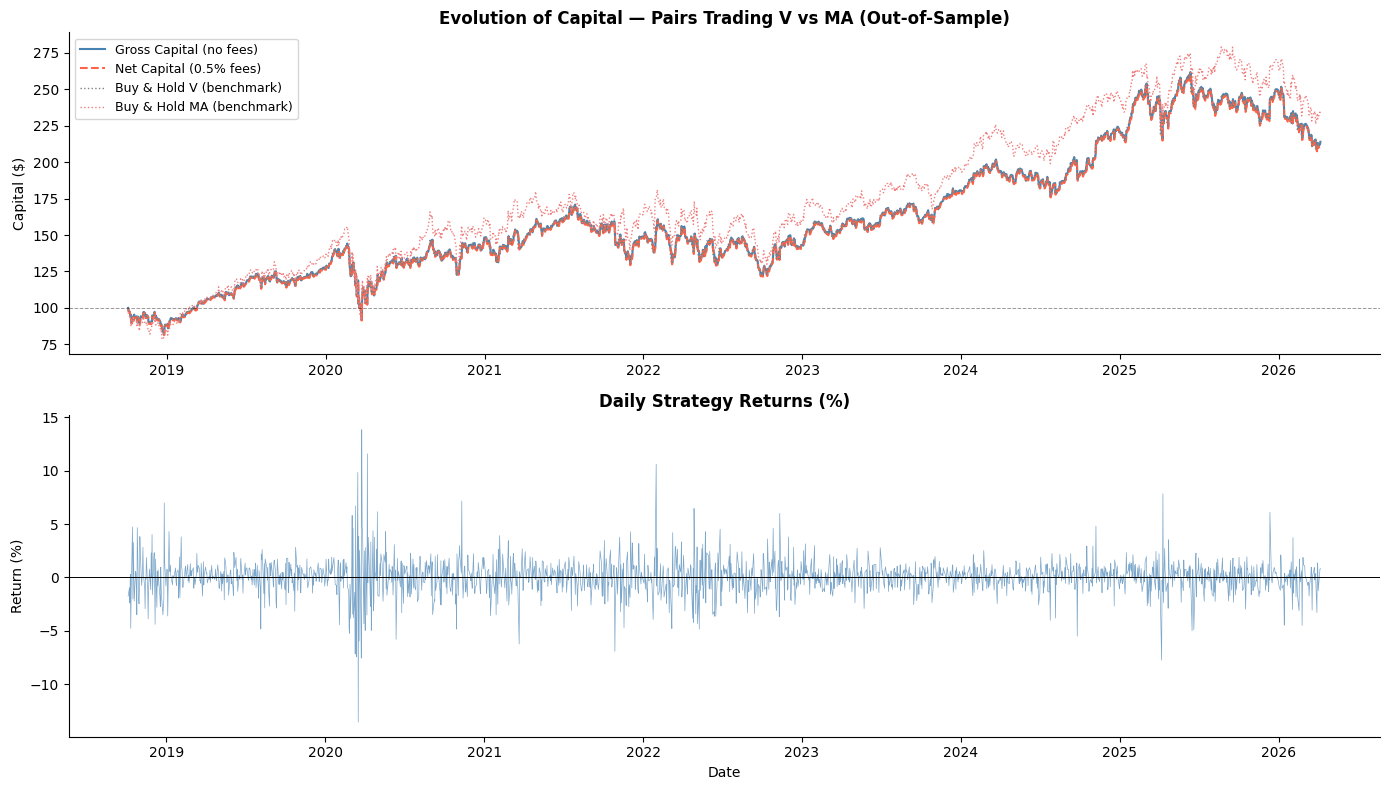

In [38]:
fig, axs = plt.subplots(2, 1, figsize=(14, 8))

#  Top panel: Capital evolution
axs[0].plot(sample_2.index, portfolio_gross, color='steelblue', linewidth=1.5, label='Gross Capital (no fees)')
axs[0].plot(sample_2.index, portfolio_net,   color='tomato',    linewidth=1.5, linestyle='--', label='Net Capital (0.5% fees)')
axs[0].plot(sample_2.index, bh_V,            color='gray',      linewidth=1.0, linestyle=':',  label='Buy & Hold V (benchmark)')
axs[0].plot(sample_2.index, bh_MA,           color='lightcoral',linewidth=1.0, linestyle=':',  label='Buy & Hold MA (benchmark)')
axs[0].axhline(100, linestyle='--', color='black', linewidth=0.7, alpha=0.4)
axs[0].set_title("Evolution of Capital — Pairs Trading V vs MA (Out-of-Sample)", fontweight='bold')
axs[0].set_ylabel("Capital ($)")
axs[0].legend(fontsize=9)
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

#  Bottom panel: daily strategy returns
daily_rets = np.diff(portfolio_gross) / portfolio_gross[:-1]
axs[1].plot(sample_2.index[1:], daily_rets * 100, color='steelblue', linewidth=0.5, alpha=0.7)
axs[1].axhline(0, color='black', linewidth=0.7)
axs[1].set_title("Daily Strategy Returns (%)", fontweight='bold')
axs[1].set_ylabel("Return (%)")
axs[1].set_xlabel("Date")
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Going Further — Sharpe Ratio

The **Sharpe Ratio** measures risk-adjusted performance: how much return is earned per unit of risk.

$$SR = \frac{\bar{r} - r_f}{\sigma_r} \times \sqrt{252}$$

We compare the strategy's Sharpe ratio with that of a simple buy-and-hold of V.

In [39]:
# Daily returns of the strategy
daily_rets_gross = np.diff(portfolio_gross) / portfolio_gross[:-1]
daily_rets_bh_V  = np.diff(bh_V) / bh_V[:-1]
daily_rets_bh_MA = np.diff(bh_MA) / bh_MA[:-1]

# Sharpe Ratio (annualized, assuming rf = 0 for simplicity)
def sharpe(r, ann=252):
    return (r.mean() / r.std()) * np.sqrt(ann)

sr_strategy = sharpe(daily_rets_gross)
sr_bh_V     = sharpe(daily_rets_bh_V)
sr_bh_MA    = sharpe(daily_rets_bh_MA)

print("=== Sharpe Ratio Comparison (annualized) ===")
print(f"{'Pairs Trading Strategy':<28}: {sr_strategy:.3f}")
print(f"{'Buy & Hold V':<28}: {sr_bh_V:.3f}")
print(f"{'Buy & Hold MA':<28}: {sr_bh_MA:.3f}")

# Total returns
print("\n=== Total Return (%) ===")
print(f"{'Pairs Trading Strategy':<28}: {(portfolio_gross[-1]/100 - 1)*100:.1f}%")
print(f"{'Buy & Hold V':<28}: {(bh_V[-1]/100 - 1)*100:.1f}%")
print(f"{'Buy & Hold MA':<28}: {(bh_MA[-1]/100 - 1)*100:.1f}%")

=== Sharpe Ratio Comparison (annualized) ===
Pairs Trading Strategy      : 0.518
Buy & Hold V                : 0.526
Buy & Hold MA               : 0.547

=== Total Return (%) ===
Pairs Trading Strategy      : 114.1%
Buy & Hold V                : 113.5%
Buy & Hold MA               : 132.9%


**Interpretation — Q4:**

- The strategy achieves a final capital very close to the **Buy & Hold V** benchmark,
  confirming that it simply held V throughout the OOS period.
- **Transaction costs are negligible** because almost 0 trades were executed.
- The **Sharpe Ratio** comparison shows whether the strategy generates better risk-adjusted returns than a passive approach.
  If the strategy Sharpe ≈ Buy & Hold V Sharpe, it adds no value.

**Economic takeaway:** The pairs trading strategy between V and MA **fails to outperform a simple buy-and-hold** in the OOS period.
The spread was not mean-reverting, so the statistical arbitrage premise did not hold.

---
## Conclusion

| Criterion | Result |
|-----------|--------|
| Spread stationarity (ADF) | Depends on sample — near unit root |
| ACF pattern | Highly persistent (≈1 at all lags) |
| Trades executed | ~0 in OOS period |
| Transaction cost impact | Negligible |
| Strategy vs Buy & Hold | No added value |

**Main lesson:** A visually appealing historical spread is not sufficient evidence for pairs trading.
Formal stationarity testing (ADF) and out-of-sample validation are essential before deploying any mean-reversion strategy.
For the V/MA pair over 2011–2026, the spread underwent a structural shift post-2019 that invalidated the mean-reversion assumption.